In [17]:
import torch
import torch.nn as nn
import numpy as np

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
# Reynolds number
RE = 100.0

# Simulation domain [0,1]x[0,1], training time [0, T]
T = 5.0

# Points distribution
N_INITIAL = 128   # interior points at t=0
N_UPPER = 128     # top boundary (lid) points
N_BOUNDARY = 32   # points per side boundary (left, right, bottom)
N_MESH = 256      # interior collocation points

# Training
EPOCHS = 5000
WARMUP_EPOCHS = 500
PDE_RAMP_EPOCHS = 2500
BASE_LR = 1e-3
PDE_WEIGHT_MAX = 0.9
LBFGS_STEPS = 150

# Stabilization
SCHEDULER_START_EPOCH = 700
EMA_ALPHA = 0.97
PDE_WEIGHT_SMOOTH = 0.97

In [ ]:
class LidDrivenCavityNN(nn.Module):
    def __init__(self, nu):
        super().__init__()
        self.nu = nu

        self.act = nn.SiLU()
        hidden_dim = 128
        num_blocks = 8

        self.input_layer = nn.Linear(3, hidden_dim)
        self.blocks = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim) for _ in range(num_blocks)])
        self.output_layer = nn.Linear(hidden_dim, 2)  # [p, psi]

    def forward(self, x, y, t):
        h = torch.cat([x, y, t], dim=1)
        h = self.act(self.input_layer(h))
        for block in self.blocks:
            h = h + self.act(block(h))  # residual connection
        return self.output_layer(h)

    def loss_fx(self, x, y, t):
        res = self.forward(x, y, t)
        p = res[:, 0:1]
        psi = res[:, 1:2]

        def d_(f, v):
            return torch.autograd.grad(
                f, v, grad_outputs=torch.ones_like(f), create_graph=True
            )[0]

        u = d_(psi, y)
        v_ = -d_(psi, x)

        u_x = d_(u, x)
        u_xx = d_(u_x, x)
        u_y = d_(u, y)
        u_yy = d_(u_y, y)
        u_t = d_(u, t)

        v_x = d_(v_, x)
        v_xx = d_(v_x, x)
        v_y = d_(v_, y)
        v_yy = d_(v_y, y)
        v_t = d_(v_, t)

        p_x = d_(p, x)
        p_y = d_(p, y)

        fx = u_t + u * u_x + v_ * u_y + p_x - self.nu * (u_xx + u_yy)
        fy = v_t + u * v_x + v_ * v_y + p_y - self.nu * (v_xx + v_yy)

        return u, v_, p, fx, fy, psi

In [ ]:
def _tensor(*size):
    return torch.rand(*size, 1, device=device).requires_grad_(True)


def generate_initial_points():
    x = _tensor(N_INITIAL)
    y = torch.rand(N_INITIAL, 1, device=device).mul_(1.0 - 1e-6).requires_grad_(True)
    t = torch.zeros(N_INITIAL, 1, device=device, requires_grad=True)
    return x, y, t


def generate_boundary_points():
    x_bc = torch.cat([
        torch.zeros(N_BOUNDARY, 1, device=device, requires_grad=True),   # left:   x=0
        torch.ones(N_BOUNDARY, 1, device=device, requires_grad=True),    # right:  x=1
        _tensor(N_BOUNDARY),                                             # bottom: random x
    ])
    y_bc = torch.cat([
        _tensor(N_BOUNDARY),                                             # left:   random y
        _tensor(N_BOUNDARY),                                             # right:  random y
        torch.zeros(N_BOUNDARY, 1, device=device, requires_grad=True),   # bottom: y=0
    ])
    t_bc = torch.rand(N_BOUNDARY * 3, 1, device=device).mul_(T).requires_grad_(True)
    return x_bc, y_bc, t_bc


def generate_upper_boundary_points():
    x = _tensor(N_UPPER)
    y = torch.ones(N_UPPER, 1, device=device, requires_grad=True)
    t = torch.rand(N_UPPER, 1, device=device).mul_(T).requires_grad_(True)
    return x, y, t


def generate_domain_points():
    x = _tensor(N_MESH)
    y = _tensor(N_MESH)
    t = torch.rand(N_MESH, 1, device=device).mul_(T).requires_grad_(True)
    return x, y, t


In [ ]:
model = LidDrivenCavityNN(1.0 / RE).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=BASE_LR)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=220,
    threshold=2e-4,
    cooldown=80,
    min_lr=1e-6,
)

In [ ]:
import datetime

loss_history = []
warmup_loss_history = []
lr_history = []

model.train()
model.to(device)

train_start = datetime.datetime.now()
lap_start = train_start
ema_main_loss = None
pde_weight_state = 0.0
best_main_loss = float("inf")
best_main_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

# Warm-up
for i in range(WARMUP_EPOCHS):
    optimizer.zero_grad()

    x_ic, y_ic, t_ic = generate_initial_points()
    u, v, _, _, _, _ = model.loss_fx(x_ic, y_ic, t_ic)
    loss_ic = torch.mean(u**2 + v**2)

    x_bc, y_bc, t_bc = generate_boundary_points()
    u, v, _, _, _, _ = model.loss_fx(x_bc, y_bc, t_bc)
    loss_bc = torch.mean(u**2 + v**2)

    x_up, y_up, t_up = generate_upper_boundary_points()
    u, v, _, _, _, _ = model.loss_fx(x_up, y_up, t_up)
    loss_up = torch.mean((u - 1.0) ** 2 + v**2)

    loss = loss_ic + loss_bc + loss_up

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    warmup_loss_history.append(loss.item())
    lr_history.append(optimizer.param_groups[0]["lr"])

    if i % 100 == 0:
        print(f"Warmup {i:4d}  Loss: {loss.item():.6f}  LR: {optimizer.param_groups[0]['lr']:.2e}")

print("Warm-up complete. Starting PDE training...")

# Main phase
for i in range(EPOCHS):
    optimizer.zero_grad()

    # Initial condition: u=0, v=0 everywhere at t=0
    x_ic, y_ic, t_ic = generate_initial_points()
    u, v, _, _, _, _ = model.loss_fx(x_ic, y_ic, t_ic)
    loss_ic = torch.mean(u**2 + v**2)

    # Left / right / bottom walls: u=0, v=0
    x_bc, y_bc, t_bc = generate_boundary_points()
    u, v, _, _, _, _ = model.loss_fx(x_bc, y_bc, t_bc)
    loss_bc = torch.mean(u**2 + v**2)

    # Top wall (lid): u=1, v=0
    x_up, y_up, t_up = generate_upper_boundary_points()
    u, v, _, _, _, _ = model.loss_fx(x_up, y_up, t_up)
    loss_up = torch.mean((u - 1.0) ** 2 + v**2)

    # Interior residual (ramp + adaptive balancing)
    x_d, y_d, t_d = generate_domain_points()
    _, _, _, fx, fy, _ = model.loss_fx(x_d, y_d, t_d)
    loss_pde_raw = torch.mean(fx**2 + fy**2)

    bc_total = (loss_ic + loss_bc + loss_up).detach()
    pde_denom = loss_pde_raw.detach() + 1e-8
    adapt_ratio = torch.sqrt(bc_total / pde_denom).item()

    ramp = min(1.0, (i + 1) / PDE_RAMP_EPOCHS)
    pde_weight_target = min(PDE_WEIGHT_MAX, PDE_WEIGHT_MAX * ramp * adapt_ratio)
    pde_weight_state = PDE_WEIGHT_SMOOTH * pde_weight_state + (1.0 - PDE_WEIGHT_SMOOTH) * pde_weight_target
    pde_weight = max(0.05, pde_weight_state)

    loss_d = pde_weight * loss_pde_raw
    loss = loss_ic + loss_bc + loss_up + loss_d

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    # Delay and smooth scheduler signal to avoid premature LR collapse
    if ema_main_loss is None:
        ema_main_loss = loss.item()
    else:
        ema_main_loss = EMA_ALPHA * ema_main_loss + (1.0 - EMA_ALPHA) * loss.item()

    if i >= SCHEDULER_START_EPOCH:
        scheduler.step(ema_main_loss)

    # Keep best main-phase checkpoint before LBFGS
    if loss.item() < best_main_loss:
        best_main_loss = loss.item()
        best_main_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

    loss_history.append(loss.item())
    lr_history.append(optimizer.param_groups[0]["lr"])

    if i % 100 == 0:
        lap_elapsed = datetime.datetime.now() - lap_start
        lap_start = datetime.datetime.now()
        print(
            f"Epoch {i:4d}  Loss: {loss.item():.6f}  PDE_w: {pde_weight:.3f}  "
            f"LR: {optimizer.param_groups[0]['lr']:.2e}  Lap: {lap_elapsed}"
        )

if LBFGS_STEPS > 0:
    print(f"Starting LBFGS fine-tune for {LBFGS_STEPS} steps...")
    model.load_state_dict(best_main_state)
    print(f"Loaded best main-phase checkpoint (loss={best_main_loss:.6f})")

    lbfgs = torch.optim.LBFGS(
        model.parameters(),
        lr=0.5,
        max_iter=LBFGS_STEPS,
        tolerance_grad=1e-8,
        tolerance_change=1e-10,
        history_size=50,
        line_search_fn="strong_wolfe",
    )

    def closure():
        lbfgs.zero_grad()

        x_ic, y_ic, t_ic = generate_initial_points()
        u, v, _, _, _, _ = model.loss_fx(x_ic, y_ic, t_ic)
        loss_ic = torch.mean(u**2 + v**2)

        x_bc, y_bc, t_bc = generate_boundary_points()
        u, v, _, _, _, _ = model.loss_fx(x_bc, y_bc, t_bc)
        loss_bc = torch.mean(u**2 + v**2)

        x_up, y_up, t_up = generate_upper_boundary_points()
        u, v, _, _, _, _ = model.loss_fx(x_up, y_up, t_up)
        loss_up = torch.mean((u - 1.0) ** 2 + v**2)

        x_d, y_d, t_d = generate_domain_points()
        _, _, _, fx, fy, _ = model.loss_fx(x_d, y_d, t_d)
        loss_d = PDE_WEIGHT_MAX * torch.mean(fx**2 + fy**2)

        total_loss = loss_ic + loss_bc + loss_up + loss_d
        total_loss.backward()
        return total_loss

    lbfgs_loss = float(lbfgs.step(closure))

    # Guard against LBFGS degradation
    x_ic, y_ic, t_ic = generate_initial_points()
    u, v, _, _, _, _ = model.loss_fx(x_ic, y_ic, t_ic)
    l_ic = torch.mean(u**2 + v**2)
    x_bc, y_bc, t_bc = generate_boundary_points()
    u, v, _, _, _, _ = model.loss_fx(x_bc, y_bc, t_bc)
    l_bc = torch.mean(u**2 + v**2)
    x_up, y_up, t_up = generate_upper_boundary_points()
    u, v, _, _, _, _ = model.loss_fx(x_up, y_up, t_up)
    l_up = torch.mean((u - 1.0) ** 2 + v**2)
    x_d, y_d, t_d = generate_domain_points()
    _, _, _, fx, fy, _ = model.loss_fx(x_d, y_d, t_d)
    l_d = PDE_WEIGHT_MAX * torch.mean(fx**2 + fy**2)
    post_lbfgs_loss = float((l_ic + l_bc + l_up + l_d).item())

    if post_lbfgs_loss <= best_main_loss:
        loss_history.append(post_lbfgs_loss)
        print(f"LBFGS accepted: {post_lbfgs_loss:.6f} (raw step={lbfgs_loss:.6f})")
    else:
        model.load_state_dict(best_main_state)
        print(f"LBFGS rejected ({post_lbfgs_loss:.6f} > {best_main_loss:.6f}); restored best main-phase weights")

train_elapsed = datetime.datetime.now() - train_start
print(f"\nTotal training time: {train_elapsed}  ({WARMUP_EPOCHS + EPOCHS} epochs + {LBFGS_STEPS} LBFGS steps)")

torch.save(model.state_dict(), "cavity.pt")
print("Model saved -> cavity.pt")

Epoch    0  Loss: 1.000003  Lap: 0:00:00.788309
Epoch  100  Loss: 0.126483  Lap: 0:01:17.024930
Epoch  200  Loss: 0.125409  Lap: 0:01:17.542090
Epoch  300  Loss: 0.083690  Lap: 0:01:17.765976
Epoch  400  Loss: 0.070838  Lap: 0:01:17.836629
Epoch  500  Loss: 0.074280  Lap: 0:01:18.360066
Epoch  600  Loss: 0.053908  Lap: 0:01:18.488068
Epoch  700  Loss: 0.066305  Lap: 0:01:18.499917
Epoch  800  Loss: 0.082909  Lap: 0:01:17.586261
Epoch  900  Loss: 0.069241  Lap: 0:01:17.311169

Total training time: 0:12:58.613750  (1000 epochs)
Model saved -> cavity.pt


In [ ]:
import time

def evaluate_on_grid(nx=50, ny=50, t_val=None):
    """Evaluate the trained model on a regular nx × ny grid."""
    if t_val is None:
        t_val = 0.8 * T

    model.eval()

    xs = torch.linspace(0, 1, nx, device=device)
    ys = torch.linspace(0, 1, ny, device=device)
    X, Y = torch.meshgrid(xs, ys, indexing="ij")  # (nx, ny)

    x_g = X.reshape(-1, 1).requires_grad_(True)
    y_g = Y.reshape(-1, 1).requires_grad_(True)
    t_g = torch.full((nx * ny, 1), t_val, device=device, requires_grad=True)

    # --- time the forward + autograd pass ---
    if device.type == "cuda":
        torch.cuda.synchronize()
    pred_start = time.perf_counter()

    u, v, p, fx, fy, psi = model.loss_fx(x_g, y_g, t_g)

    if device.type == "cuda":
        torch.cuda.synchronize()
    pred_elapsed = time.perf_counter() - pred_start
    print(f"Prediction time ({nx}×{ny} grid, {nx*ny} points): {pred_elapsed*1e3:.2f} ms")

    def to_grid(tensor):
        return tensor.detach().cpu().numpy().reshape(nx, ny)

    return (
        X.cpu().numpy(), Y.cpu().numpy(),
        to_grid(u), to_grid(v), to_grid(p),
        to_grid(fx), to_grid(fy), to_grid(psi),
    )


Prediction time (50×50 grid, 2500 points): 139.91 ms
Predictions saved -> pinn_predictions.csv  (2500 rows)
Figure saved -> pinn_lid_cavity_results.png


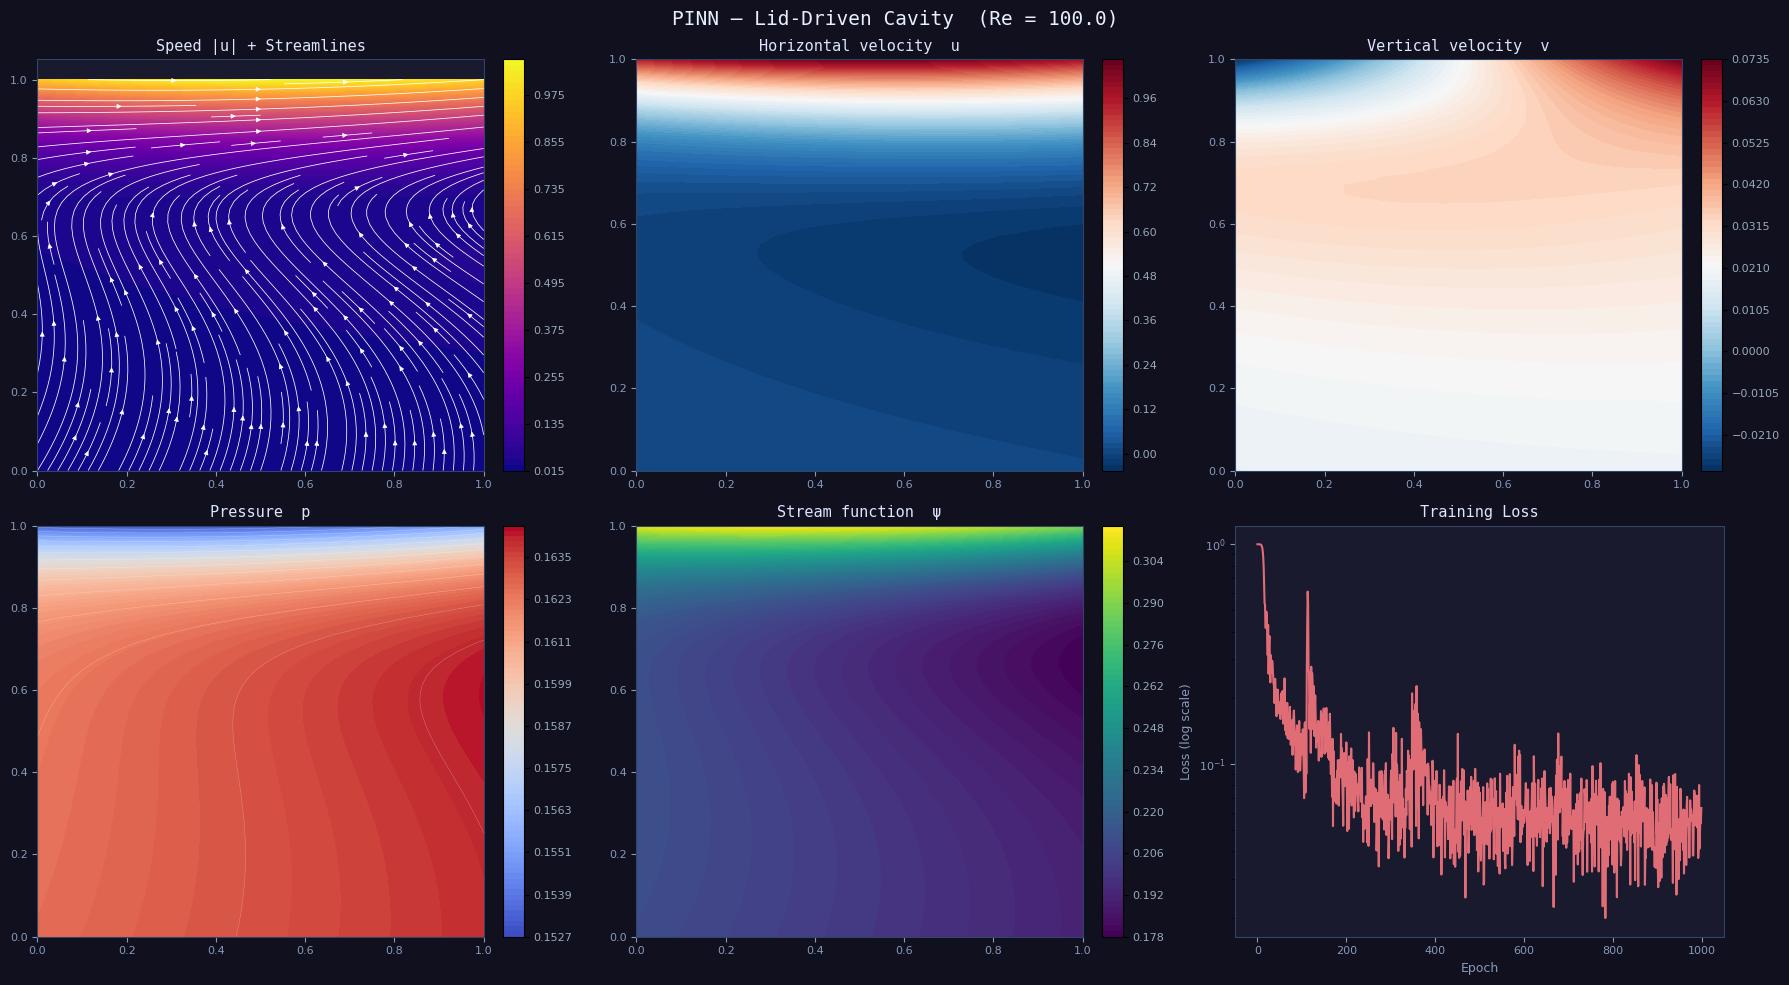

In [ ]:
X, Y, U, V, P, Fx, Fy, PSI = evaluate_on_grid(nx=50, ny=50)

# dump predictions
import pandas as pd

df = pd.DataFrame({
    "x": X.ravel(),
    "y": Y.ravel(),
    "u": U.ravel(),
    "v": V.ravel(),
    "p": P.ravel(),
    "fx": Fx.ravel(),
    "fy": Fy.ravel(),
    "psi": PSI.ravel(),
})
csv_path = "pinn_predictions.csv"
df.to_csv(csv_path, index=False)
print(f"Predictions saved -> {csv_path}  ({len(df)} rows)")

speed = np.hypot(U, V)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor("#10101e")

def styled(ax, title):
    ax.set_facecolor("#1a1a2e")
    ax.set_title(title, color="#dde4ff", fontfamily="monospace", fontsize=11)
    ax.tick_params(colors="#8899bb", labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor("#334466")

# Speed + streamlines
ax = axes[0, 0]
cf = ax.contourf(X, Y, speed, levels=80, cmap="plasma")
ax.streamplot(X.T, Y.T, U.T, V.T, color="white", linewidth=0.55, density=1.5, arrowsize=0.7)
fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04).ax.tick_params(labelcolor="#9ab", labelsize=8)
styled(ax, "Speed |u| + Streamlines")

# u velocity
ax = axes[0, 1]
cf = ax.contourf(X, Y, U, levels=80, cmap="RdBu_r")
fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04).ax.tick_params(labelcolor="#9ab", labelsize=8)
styled(ax, "Horizontal velocity  u")

# v velocity
ax = axes[0, 2]
cf = ax.contourf(X, Y, V, levels=80, cmap="RdBu_r")
fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04).ax.tick_params(labelcolor="#9ab", labelsize=8)
styled(ax, "Vertical velocity  v")

# Pressure
ax = axes[1, 0]
cf = ax.contourf(X, Y, P, levels=80, cmap="coolwarm")
ax.contour(X, Y, P, levels=15, colors="white", linewidths=0.3, alpha=0.4)
fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04).ax.tick_params(labelcolor="#9ab", labelsize=8)
styled(ax, "Pressure  p")

# Stream function
ax = axes[1, 1]
cf = ax.contourf(X, Y, PSI, levels=80, cmap="viridis")
fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04).ax.tick_params(labelcolor="#9ab", labelsize=8)
styled(ax, "Stream function  psi")

# Training loss (warm-up + main)
ax = axes[1, 2]
ax.set_facecolor("#1a1a2e")
combined_loss = warmup_loss_history + loss_history
ax.semilogy(combined_loss, color="#e06c75", lw=1.5, label="loss")
ax.axvline(WARMUP_EPOCHS, color="#ffd166", linestyle="--", linewidth=1.5, label="warm-up end")
ax.set_title("Training Loss", color="#dde4ff", fontfamily="monospace", fontsize=11)
ax.set_xlabel("Epoch", color="#8899bb", fontsize=9)
ax.set_ylabel("Loss (log scale)", color="#8899bb", fontsize=9)
ax.tick_params(colors="#8899bb", labelsize=8)
ax.legend(loc="best", fontsize=8)
for spine in ax.spines.values():
    spine.set_edgecolor("#334466")

fig.suptitle(
    f"PINN - Lid-Driven Cavity  (Re = {RE})",
    color="#e8f0ff", fontsize=14, fontfamily="monospace", y=0.98,
)
plt.tight_layout()
plt.savefig("pinn_lid_cavity_results.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
print("Figure saved -> pinn_lid_cavity_results.png")
plt.show()

# Optional LR curve for debugging plateaus
plt.figure(figsize=(8, 3.5))
plt.plot(lr_history, color="#61afef", lw=1.2)
plt.yscale("log")
plt.axvline(WARMUP_EPOCHS, color="#ffd166", linestyle="--", linewidth=1.2)
plt.title("Learning Rate Schedule", fontfamily="monospace")
plt.xlabel("Iteration")
plt.ylabel("LR (log)")
plt.tight_layout()
plt.show()

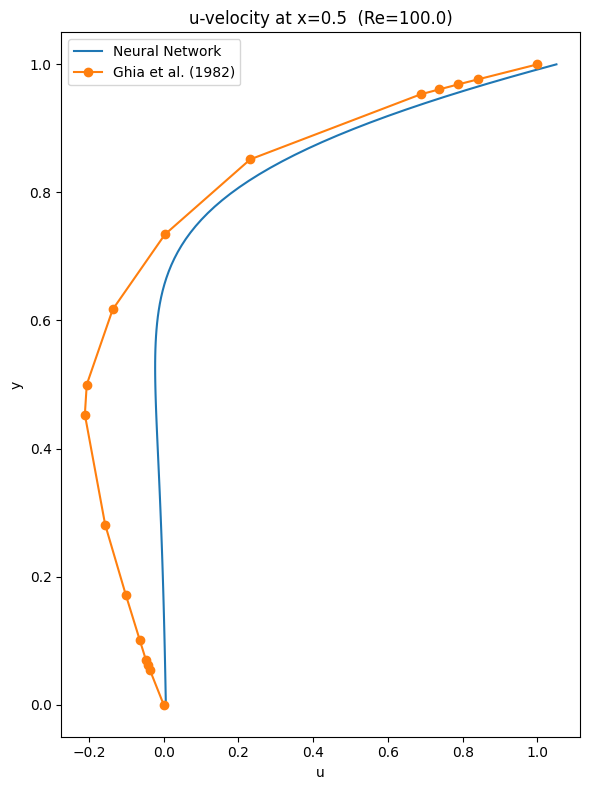

In [ ]:
# Ghia et al. (1982) benchmark: u-velocity along vertical centreline x=0.5, Re=100
ghia_y = [1.00000, 0.9766, 0.9688, 0.9609, 0.9531, 0.8516, 0.7344,
          0.6172, 0.5000, 0.4531, 0.2813, 0.1719, 0.1016, 0.0703,
          0.0625, 0.0547, 0.0000]
ghia_u = [1.00000, 0.84123, 0.78871, 0.73722, 0.68717, 0.23151, 0.00332,
          -0.13641, -0.20581, -0.21090, -0.15662, -0.10150, -0.06434,
          -0.04775, -0.04192, -0.03717, 0.00000]

# Sample u along x=0.5 from the model
ys_line = np.linspace(0, 1, 100)
xs_line = np.full_like(ys_line, 0.5)
ts_line = np.full_like(ys_line, 0.8 * T)

x_l = torch.tensor(xs_line.reshape(-1, 1), dtype=torch.float32, device=device).requires_grad_(True)
y_l = torch.tensor(ys_line.reshape(-1, 1), dtype=torch.float32, device=device).requires_grad_(True)
t_l = torch.tensor(ts_line.reshape(-1, 1), dtype=torch.float32, device=device).requires_grad_(True)
u_line, *_ = model.loss_fx(x_l, y_l, t_l)
u_line = u_line.detach().cpu().numpy().reshape(-1)

plt.figure(figsize=(6, 8))
plt.plot(u_line, ys_line, label="Neural Network")
plt.plot(ghia_u, ghia_y, "o-", label="Ghia et al. (1982)")
plt.xlabel("u")
plt.ylabel("y")
plt.title(f"u-velocity at x=0.5  (Re={RE})")
plt.legend()
plt.tight_layout()
plt.show()
